# Hier-COS Current-Run Trade-Off Plots

This notebook reads seeded Hier-COS output directories from `/scratch/g.saggini1/outputs` and aggregates their independently selected test checkpoints.

Included runs:
- global- and level-softmax no-lex baselines;
- global- and level-softmax coarse-first `orthogonalize_all`;
- global-softmax fine-first `orthogonalize_all` as the available priority-direction reference;
- equal and `kl_leaf` weighting when a completed run is available;
- global- and level-softmax identity-frame no-lex baselines and coarse-first runs when available.

`conflict_only` and other transform ablations are intentionally excluded. Points and tables report mean ± sample standard deviation across training seeds. All plots use the independently selected checkpoint from each seed. FPA and level accuracy are higher-is-better; TICE is lower-is-better.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

plt.style.use('seaborn-v0_8-whitegrid')

OUTPUTS_ROOT = Path('/scratch/g.saggini1/outputs')
SAVE_FIGURES = False
FIGURE_DIR = OUTPUTS_ROOT / 'analysis' / 'hiercos_current_runs'

DATASETS = {
    'cifar100': 'CIFAR-100',
    'cub200': 'CUB-200',
    'aircraft': 'Aircraft',
}

RUN_REQUESTS = [
    # Add runs as: (softmax, weighting, priority[, frame]).
    # softmax: 'global' or 'level'; weighting: 'equal' or 'kl_leaf';
    # priority: 'no_lex', 'coarse_first', or 'fine_first'; frame: 'orthonormal' or 'identity'.
    ('global', 'equal', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex'),
    ('global', 'kl_leaf', 'no_lex', 'identity'),
    ('global', 'equal', 'coarse_first'),
    ('global', 'equal', 'coarse_first', 'identity'),
    ('global', 'equal', 'fine_first'),
    # ('global', 'kl_leaf', 'coarse_first'),
    ('level', 'kl_leaf', 'no_lex'),
    ('level', 'kl_leaf', 'no_lex', 'identity'),
    ('level', 'equal', 'coarse_first'),
    ('level', 'equal', 'coarse_first', 'identity'),
    # ('level', 'kl_leaf', 'coarse_first'),
]

SOFTMAX_SPECS = {
    'global': {'loss': 'global_softmax_ce_reg', 'label': 'Global', 'code': 'G'},
    'level': {'loss': 'level_softmax_ce_reg', 'label': 'Level', 'code': 'L'},
}

LOSS_COLORS = {'Global': '#0072B2', 'Level': '#D55E00'}
MODE_LABELS = {'no_lex': 'No lex', 'coarse_first': 'Coarse-first lex', 'fine_first': 'Fine-first lex'}
MODE_CODES = {'no_lex': 'N', 'coarse_first': 'C', 'fine_first': 'F'}
WEIGHT_CODES = {'equal': 'E', 'kl_leaf': 'K'}
WEIGHT_LABELS = {'equal': 'Equal', 'kl_leaf': 'kl_leaf'}

if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [12]:
def load_test_metrics(path):
    with Path(path).open('r', encoding='utf-8') as handle:
        return yaml.safe_load(handle)


def seed_dirs(run_dir):
    candidates = []
    for child in Path(run_dir).iterdir() if Path(run_dir).is_dir() else []:
        if not child.is_dir() or not child.name.startswith('seed_'):
            continue
        try:
            seed = int(child.name.removeprefix('seed_'))
        except ValueError:
            continue
        if (child / 'test_metrics.yaml').is_file():
            candidates.append((seed, child))
    return [path for _, path in sorted(candidates)]


def sample_stats(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return np.nan, np.nan
    return float(values.mean()), float(values.std(ddof=1)) if values.size > 1 else np.nan


def run_suffix(mode, weight, frame):
    if mode == 'no_lex':
        suffix = f'baseline_{weight}'
    else:
        suffix = f'lex_orthogonalize_all_{mode}'
        if weight != 'equal':
            suffix += f'_{weight}'
    if frame == 'identity':
        suffix += '_identity'
    return suffix


def expand_run_request(request):
    softmax, weight, mode, *rest = request
    frame = rest[0] if rest else 'orthonormal'
    softmax_spec = SOFTMAX_SPECS[softmax]
    frame_code = '-ID' if frame == 'identity' else ''
    display_frame = ' identity' if frame == 'identity' else ''
    return {
        'key': '_'.join(part for part in (softmax, weight, mode, frame) if part != 'orthonormal'),
        'softmax': softmax,
        'loss': softmax_spec['loss'],
        'loss_label': softmax_spec['label'],
        'loss_code': softmax_spec['code'],
        'weight': weight,
        'weight_label': WEIGHT_LABELS[weight],
        'mode': mode,
        'mode_label': MODE_LABELS[mode],
        'frame': frame,
        'suffix': run_suffix(mode, weight, frame),
        'short_label': f"{softmax_spec['code']}-{MODE_CODES[mode]} [{WEIGHT_CODES[weight]}{frame_code}]",
        'plot_label': f"{MODE_LABELS[mode]}{display_frame}",
    }


RUN_SPECS = [expand_run_request(request) for request in RUN_REQUESTS]


def discover_rows():
    rows = []
    missing = []
    for dataset_key, dataset_label in DATASETS.items():
        for spec in RUN_SPECS:
            run_name = f"hiercos_{dataset_key}_{spec['loss']}_{spec['suffix']}"
            run_dir = OUTPUTS_ROOT / run_name
            completed_seed_dirs = seed_dirs(run_dir)
            if not completed_seed_dirs:
                missing.append((dataset_label, spec['key'], run_name))
                continue

            seed_values = {}
            for seed_dir in completed_seed_dirs:
                seed = int(seed_dir.name.removeprefix('seed_'))
                selected = load_test_metrics(seed_dir / 'test_metrics.yaml')['independent']
                metrics = selected['test_metrics']
                seed_values[seed] = {
                    'best_epoch': float(selected['best_epoch']),
                    'fpa': 100.0 * float(metrics['fpa_independent']),
                    'tice': 100.0 * float(metrics['tice_independent']),
                    **{
                        f'acc_level_{level}': 100.0 * float(metrics[f'acc_level_independent_{level}'])
                        for level in range(3)
                    },
                }
            best_epoch, best_epoch_std = sample_stats([values['best_epoch'] for values in seed_values.values()])
            fpa, fpa_std = sample_stats([values['fpa'] for values in seed_values.values()])
            tice, tice_std = sample_stats([values['tice'] for values in seed_values.values()])
            row = {
                **spec,
                'dataset': dataset_label,
                'dataset_key': dataset_key,
                'run_name': run_name,
                'seeds': sorted(seed_values),
                'seed_values': seed_values,
                'best_epoch': best_epoch,
                'best_epoch_std': best_epoch_std,
                'fpa': fpa,
                'fpa_std': fpa_std,
                'tice': tice,
                'tice_std': tice_std,
            }
            for level in range(3):
                mean, std = sample_stats([values[f'acc_level_{level}'] for values in seed_values.values()])
                row[f'acc_level_{level}'] = mean
                row[f'acc_level_{level}_std'] = std
            rows.append(row)
    return rows, missing


def mark_pareto(rows):
    for dataset in DATASETS.values():
        subset = [row for row in rows if row['dataset'] == dataset]
        for row in subset:
            dominators = [
                other['short_label'] for other in subset if other is not row
                and other['fpa'] >= row['fpa'] and other['tice'] <= row['tice']
                and (other['fpa'] > row['fpa'] or other['tice'] < row['tice'])
            ]
            row['pareto_optimal'] = not dominators
            row['dominated_by'] = dominators
    return rows


def matched_baseline(row, rows):
    return next((
        candidate for candidate in rows
        if candidate['dataset'] == row['dataset']
        and candidate['loss'] == row['loss']
        and candidate['weight'] == row['weight']
        and candidate['frame'] == row['frame']
        and candidate['mode'] == 'no_lex'
    ), None)


def matched_lex_pairs(rows):
    pairs = []
    for row in rows:
        if row['mode'] == 'no_lex':
            continue
        baseline = matched_baseline(row, rows)
        if baseline is not None:
            pairs.append({'run': row, 'baseline': baseline})
    return pairs


def point_legend_handles():
    return [
        Line2D([], [], color=LOSS_COLORS['Global'], linewidth=4, label='Global softmax'),
        Line2D([], [], color=LOSS_COLORS['Level'], linewidth=4, label='Level softmax'),
        Line2D([], [], color='#555555', marker='o', linestyle='None',
               markersize=8, label='Equal weighting'),
        Line2D([], [], color='#555555', marker='^', linestyle='None',
               markersize=9, label='kl_leaf weighting'),
        Line2D([], [], color='black', marker='x', linestyle='None',
               markersize=8, markeredgewidth=1.5, label='Identity fixed frame'),
        Line2D([], [], color='#555555', marker='.', linestyle='None',
               markersize=6, alpha=0.35, label='Individual seed'),
        Ellipse((0, 0), 1.0, 0.5, facecolor='#777777', edgecolor='#777777',
                alpha=0.15, label='1-SD covariance ellipse'),
        Line2D([], [], color=LOSS_COLORS['Global'], linewidth=1.8, linestyle='-',
               label='Global coarse-first relative to baseline'),
        Line2D([], [], color=LOSS_COLORS['Global'], linewidth=1.8, linestyle='--',
               label='Global fine-first relative to baseline'),
    ]


def add_covariance_ellipse(ax, row, color):
    points = np.asarray([
        [values['tice'], values['fpa']]
        for values in row['seed_values'].values()
    ], dtype=float)
    if points.shape[0] < 3:
        return
    covariance = np.cov(points, rowvar=False, ddof=1)
    if covariance.shape != (2, 2) or not np.all(np.isfinite(covariance)):
        return
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse(
        (row['tice'], row['fpa']),
        width=2.0 * np.sqrt(eigenvalues[0]),
        height=2.0 * np.sqrt(eigenvalues[1]),
        angle=angle,
        facecolor=color,
        edgecolor=color,
        alpha=0.12,
        linewidth=1.0,
        zorder=2,
    )
    ax.add_patch(ellipse)


def save_or_show(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / filename, bbox_inches='tight')
    plt.show()


rows, missing_runs = discover_rows()
rows = mark_pareto(rows)
for dataset in DATASETS.values():
    available = [row['short_label'] for row in rows if row['dataset'] == dataset]
    print(f'{dataset}: {", ".join(available)}')
print(f'Optional run specifications not found: {len(missing_runs)}')

CIFAR-100: G-N [E], G-N [K], G-N [K-ID], G-C [E], G-F [E], L-N [K], L-N [K-ID], L-C [E]
CUB-200: G-N [E], G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-F [E], L-N [K], L-N [K-ID], L-C [E], L-C [E-ID]
Aircraft: G-N [E], G-N [K], G-N [K-ID], G-C [E], G-C [E-ID], G-F [E], L-N [K], L-N [K-ID], L-C [E], L-C [E-ID]
Optional run specifications not found: 2


## Independent FPA–TICE Trade-Off

The plot avoids combined shape/fill encodings:
- circles identify equal weighting and triangles identify `kl_leaf` weighting;
- color identifies global versus level softmax;
- a black × overlay identifies the identity fixed frame;
- direct labels identify no lex, coarse-first lex, and fine-first lex points;
- solid and dashed segments connect global-softmax coarse-first and fine-first runs, respectively, to the global-softmax, no-lex, `kl_leaf` baseline.

Higher FPA and lower TICE are preferred.

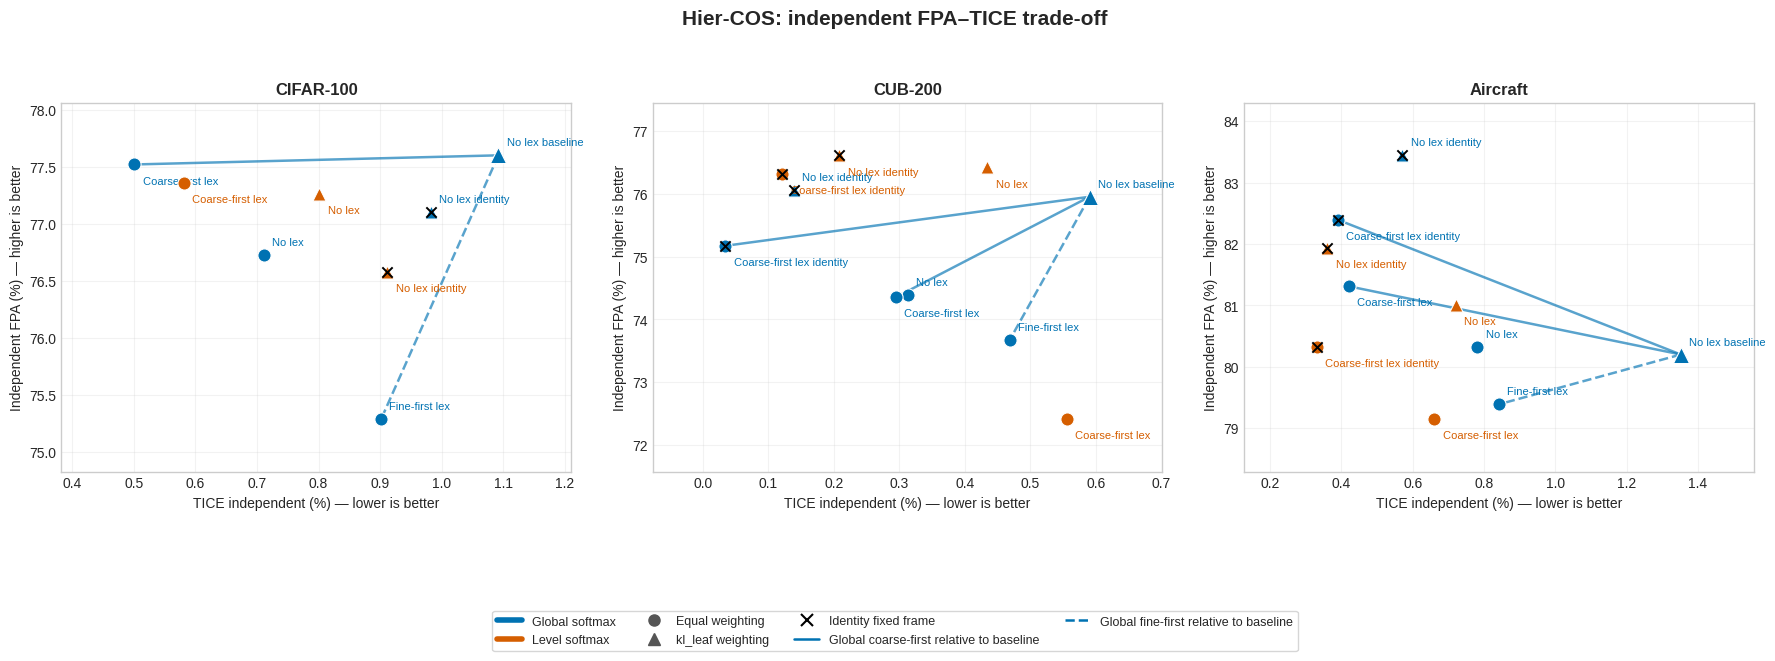

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, dataset in zip(axes, DATASETS.values()):
    subset = [row for row in rows if row['dataset'] == dataset]

    reference = next(
        row for row in subset
        if row['loss_label'] == 'Global'
        and row['weight'] == 'kl_leaf'
        and row['mode'] == 'no_lex'
    )

    # Only global-softmax lex runs are compared with the canonical no-lex kl_leaf baseline.
    for row in subset:
        if row['loss_label'] != 'Global' or row['mode'] not in {'coarse_first', 'fine_first'}:
            continue
        linestyle = '-' if row['mode'] == 'coarse_first' else '--'
        ax.plot(
            [reference['tice'], row['tice']], [reference['fpa'], row['fpa']],
            color=LOSS_COLORS['Global'], linewidth=1.8, linestyle=linestyle,
            alpha=0.65, zorder=1,
        )

    for row in subset:
        color = LOSS_COLORS[row['loss_label']]
        marker = 'o' if row['weight'] == 'equal' else '^'
        point_size = 135 if row is reference else 90
        seed_points = list(row['seed_values'].values())
        ax.scatter(
            [point['tice'] for point in seed_points],
            [point['fpa'] for point in seed_points],
            marker=marker, s=24, facecolor=color, edgecolor='none',
            alpha=0.28, zorder=2,
        )
        add_covariance_ellipse(ax, row, color)
        ax.scatter(
            row['tice'], row['fpa'], marker=marker, s=point_size,
            facecolor=color, edgecolor='white', linewidth=0.8, zorder=3,
        )
        is_identity = row.get('frame') == 'identity'
        if is_identity:
            ax.scatter(
                row['tice'], row['fpa'], marker='x', s=55,
                color='black', linewidth=1.4, zorder=4,
            )
        if row is reference:
            label = 'No lex baseline'
        else:
            label = row['plot_label']
        if row['loss_label'] == 'Level' or row['mode'] == 'coarse_first':
            y_offset = -14
        else:
            y_offset = 7
        ax.annotate(
            label, (row['tice'], row['fpa']), xytext=(6, y_offset),
            textcoords='offset points', fontsize=8, color=color,
        )

    ax.set_title(dataset, fontweight='bold')
    ax.set_xlabel('TICE independent (%) — lower is better')
    ax.set_ylabel('Independent FPA (%) — higher is better')
    ax.margins(x=0.20, y=0.20)
    ax.grid(True, alpha=0.25)

fig.legend(
    handles=point_legend_handles(), loc='lower center', ncol=4,
    bbox_to_anchor=(0.5, -0.10), frameon=True, fontsize=9,
)
fig.suptitle('Hier-COS: independent FPA–TICE trade-off', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0.12, 1, 0.94))
save_or_show(fig, 'fpa_tice_tradeoff_all_softmax.svg')

## Lex Effect Across Hierarchy Levels

Each bar is the independent level-accuracy change from a matched no-lex baseline with the same loss and weighting. Runs without a matching baseline are omitted from this causal comparison rather than being compared across different objectives.

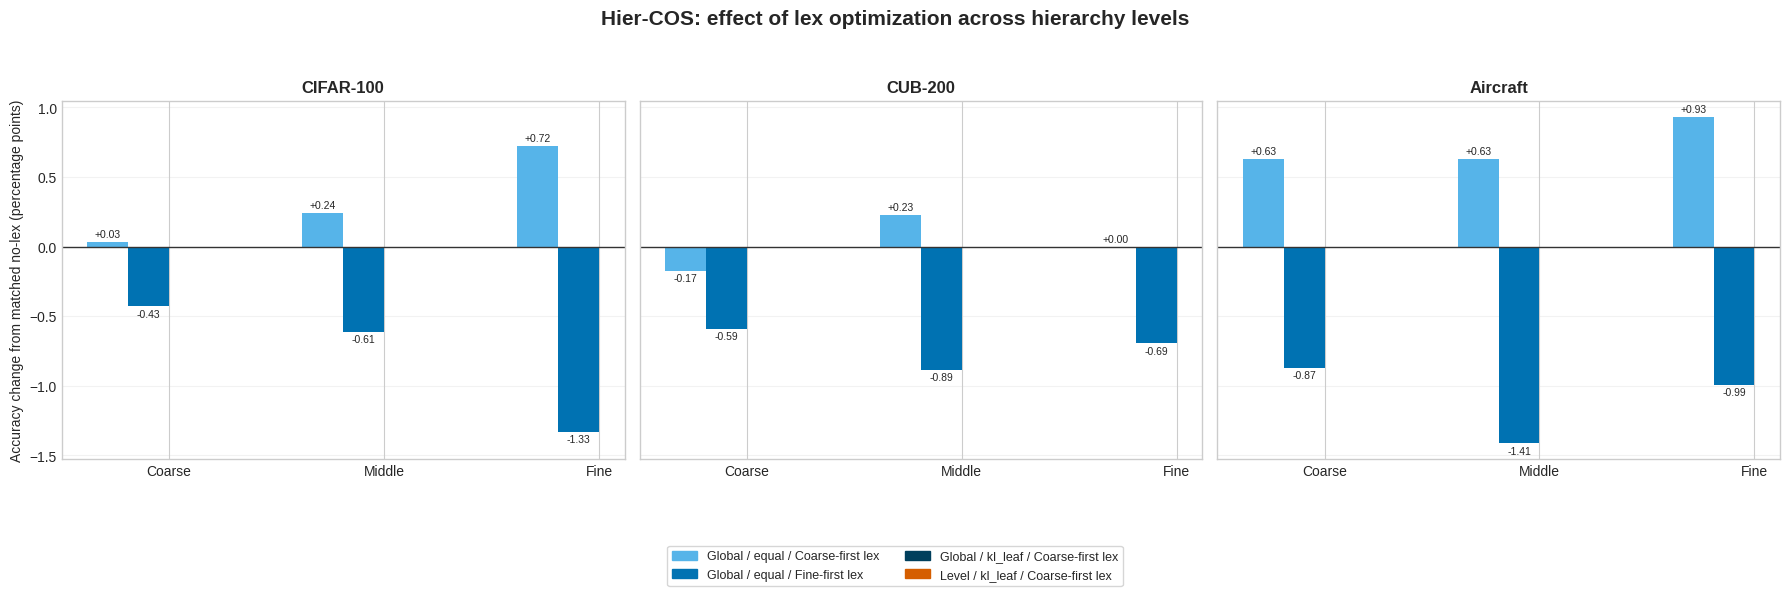

In [14]:
pairs = matched_lex_pairs(rows)
comparison_specs = [
    (('Global', 'equal', 'coarse_first'), 'Global / equal / Coarse-first lex', '#56B4E9'),
    (('Global', 'equal', 'fine_first'), 'Global / equal / Fine-first lex', '#0072B2'),
    (('Global', 'kl_leaf', 'coarse_first'), 'Global / kl_leaf / Coarse-first lex', '#003F5C'),
    (('Level', 'kl_leaf', 'coarse_first'), 'Level / kl_leaf / Coarse-first lex', '#D55E00'),
]
level_labels = ['Coarse', 'Middle', 'Fine']
x = np.arange(3)
width = 0.19

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
for ax, dataset in zip(axes, DATASETS.values()):
    dataset_pairs = [pair for pair in pairs if pair['run']['dataset'] == dataset]
    for index, (style_key, label, color) in enumerate(comparison_specs):
        pair = next((
            pair for pair in dataset_pairs
            if (pair['run']['loss_label'], pair['run']['weight'], pair['run']['mode']) == style_key
        ), None)
        if pair is None:
            continue
        run, baseline = pair['run'], pair['baseline']
        common_seeds = sorted(set(run['seeds']) & set(baseline['seeds']))
        if not common_seeds:
            continue
        delta_samples = np.asarray([
            [
                run['seed_values'][seed][f'acc_level_{level}']
                - baseline['seed_values'][seed][f'acc_level_{level}']
                for level in range(3)
            ]
            for seed in common_seeds
        ], dtype=float)
        deltas = delta_samples.mean(axis=0)
        delta_stds = delta_samples.std(axis=0, ddof=1) if len(common_seeds) > 1 else np.full(3, np.nan)
        positions = x + (index - (len(comparison_specs) - 1) / 2) * width
        yerr = delta_stds if np.all(np.isfinite(delta_stds)) else None
        bars = ax.bar(
            positions, deltas, width=width, color=color, label=label, zorder=2,
            yerr=yerr, capsize=3, error_kw={'linewidth': 1.0},
        )
        ax.bar_label(bars, fmt='%+.2f', fontsize=7.5, padding=2)
    ax.axhline(0, color='#333333', linewidth=1)
    ax.set_title(dataset, fontweight='bold')
    ax.set_xticks(x, level_labels)
    ax.grid(True, axis='y', alpha=0.25)
axes[0].set_ylabel('Accuracy change from matched no-lex (percentage points)')
handles = [
    plt.Rectangle((0, 0), 1, 1, color=color, label=label)
    for _, label, color in comparison_specs
]
fig.legend(
    handles=handles, loc='lower center', ncol=2,
    bbox_to_anchor=(0.5, -0.08), frameon=True, fontsize=9,
)
fig.suptitle('Hier-COS: effect of lex optimization across hierarchy levels', fontsize=15, fontweight='bold')
fig.tight_layout(rect=(0, 0.10, 1, 0.94))
save_or_show(fig, 'level_accuracy_matched_lex_deltas.svg')

## Run and Pareto Summary

A point is Pareto-optimal when no available run for the same dataset has both higher-or-equal FPA and lower-or-equal TICE, with at least one strict improvement.

In [15]:
for dataset in DATASETS.values():
    print(f'\n{dataset}')
    print('  code       n   epoch             FPA               TICE              status')
    for row in sorted((r for r in rows if r['dataset'] == dataset), key=lambda r: (-r['fpa'], r['tice'])):
        status = 'Pareto-optimal' if row['pareto_optimal'] else 'dominated by ' + ', '.join(row['dominated_by'])
        epoch_text = f"{row['best_epoch']:.1f} ± {row['best_epoch_std']:.1f}" if np.isfinite(row['best_epoch_std']) else f"{row['best_epoch']:.0f}"
        fpa_text = f"{row['fpa']:.2f}% ± {row['fpa_std']:.2f}" if np.isfinite(row['fpa_std']) else f"{row['fpa']:.2f}%"
        tice_text = f"{row['tice']:.2f}% ± {row['tice_std']:.2f}" if np.isfinite(row['tice_std']) else f"{row['tice']:.2f}%"
        print(
            f"  {row['short_label']:<10} {len(row['seeds']):>2}  {epoch_text:<17} "
            f"{fpa_text:<17} {tice_text:<17} {status}"
        )


CIFAR-100
  code       epoch    FPA      TICE     status
  G-N [K]       89   77.60%    1.09%  Pareto-optimal
  G-C [E]       95   77.52%    0.50%  Pareto-optimal
  L-C [E]       96   77.36%    0.58%  dominated by G-C [E]
  L-N [K]       92   77.26%    0.80%  dominated by G-C [E], L-C [E]
  G-N [K-ID]    98   77.10%    0.98%  dominated by G-C [E], L-N [K], L-C [E]
  G-N [E]       95   76.73%    0.71%  dominated by G-C [E], L-C [E]
  L-N [K-ID]    99   76.58%    0.91%  dominated by G-N [E], G-C [E], L-N [K], L-C [E]
  G-F [E]       96   75.29%    0.90%  dominated by G-N [E], G-C [E], L-N [K], L-C [E]

CUB-200
  code       epoch    FPA      TICE     status
  L-N [K-ID]    62   76.61%    0.21%  Pareto-optimal
  L-N [K]       66   76.42%    0.43%  dominated by L-N [K-ID]
  L-C [E-ID]    81   76.32%    0.12%  Pareto-optimal
  G-N [K-ID]    78   76.06%    0.14%  dominated by L-C [E-ID]
  G-N [K]       83   75.95%    0.59%  dominated by G-N [K-ID], L-N [K], L-N [K-ID], L-C [E-ID]
  G-C [E-ID